In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from skimage import util
from skimage.filters import threshold_otsu
from skimage.io import imread
from skimage.measure import label, regionprops_table
from skimage.morphology import closing, disk, opening, remove_small_holes
from skimage.segmentation import expand_labels
import contextlib
import joblib
from joblib import Parallel, delayed
from tqdm import tqdm

In [ ]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """
    Enables parallel jobs to run and display of a tqdm progress bar.

    Parameters:
    -----------
    tqdm_object : tqdm
        The tqdm progress bar instance to be updated.

    """
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [80]:
image_folder = Path(r"Z:\\Bel\\Marina_Area_PDO\\260310")
png_stack = imread(image_folder / "marina_area_stack.tif")
segmented_stack = imread(image_folder / "marina_segmented_stack.tif")

slice 0: method=fallback from segmented stack, solidity=0.959


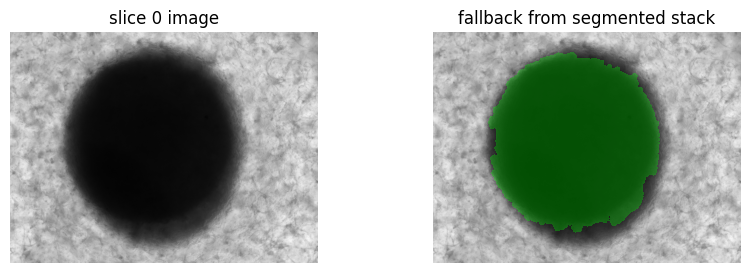

slice 1: method=fallback from segmented stack, solidity=0.953


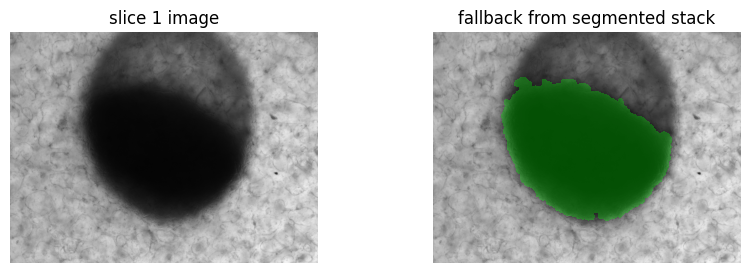

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_469568\2286620315.py:4: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  eroded = binary_erosion(mask, footprint=disk(radius))


slice 2: method=fallback with branch pruning, solidity=0.859


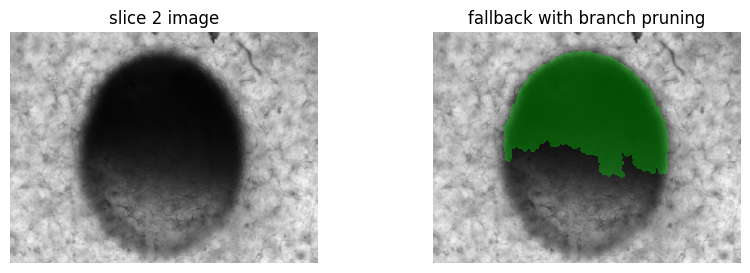

slice 3: method=fallback from segmented stack, solidity=0.963


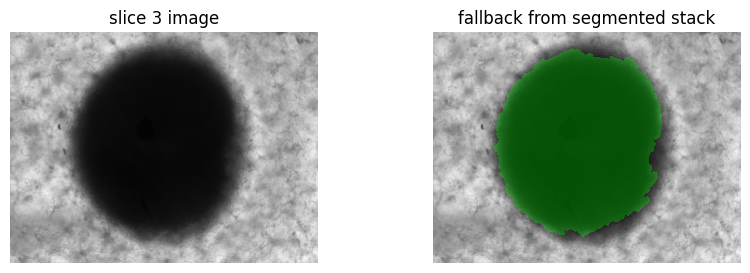

slice 4: method=fallback from segmented stack, solidity=0.957


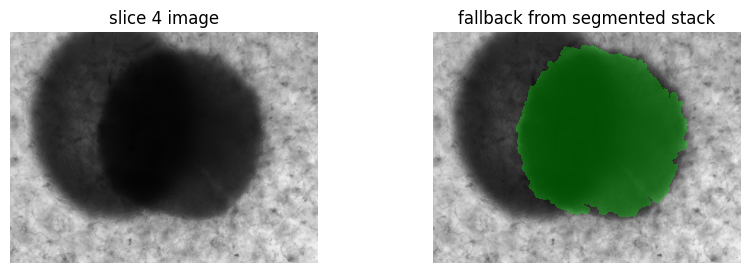

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_469568\2286620315.py:4: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  eroded = binary_erosion(mask, footprint=disk(radius))


slice 5: method=fallback with branch pruning, solidity=0.896


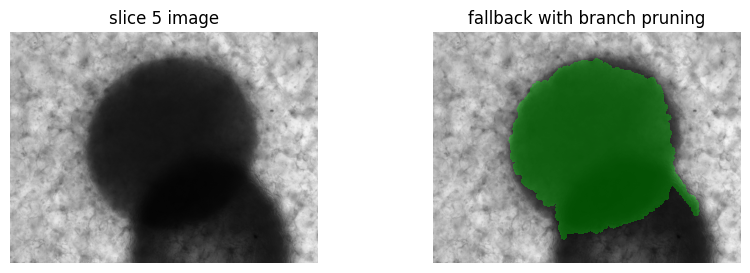

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_469568\2286620315.py:4: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  eroded = binary_erosion(mask, footprint=disk(radius))


slice 6: method=fallback with branch pruning, solidity=0.934


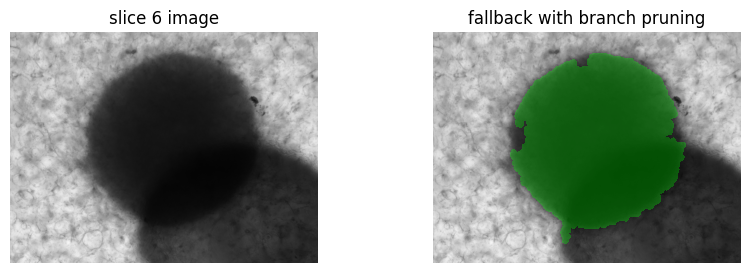

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_469568\2286620315.py:4: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  eroded = binary_erosion(mask, footprint=disk(radius))


slice 7: method=fallback with branch pruning, solidity=0.917


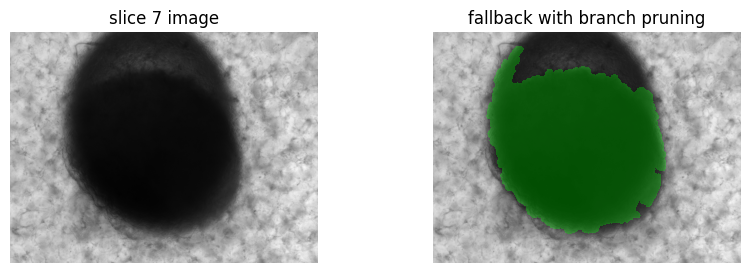

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_469568\2286620315.py:4: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  eroded = binary_erosion(mask, footprint=disk(radius))


slice 8: method=fallback with branch pruning, solidity=0.870


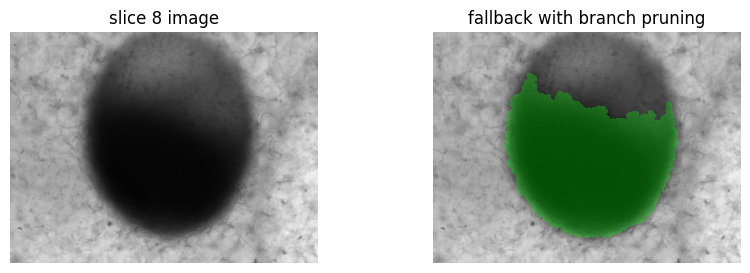

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_469568\2286620315.py:4: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  eroded = binary_erosion(mask, footprint=disk(radius))


slice 9: method=fallback with branch pruning, solidity=0.771


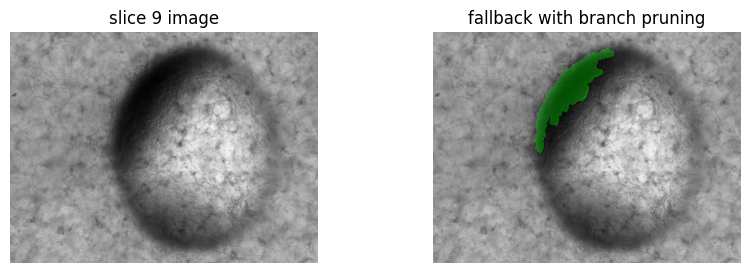

slice 10: method=fallback from segmented stack, solidity=0.959


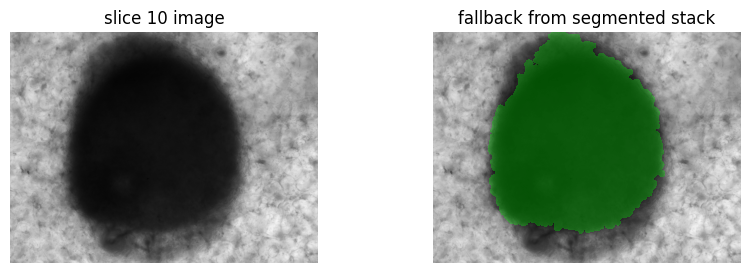

slice 11: method=fallback from segmented stack, solidity=0.957


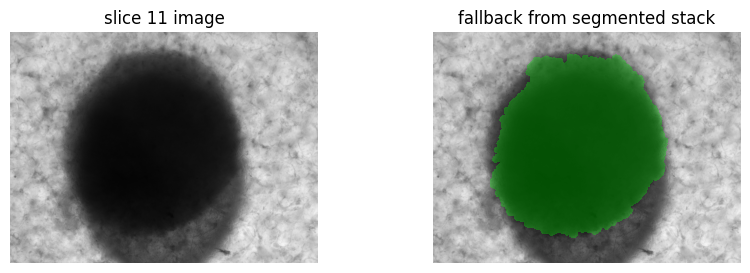

In [ ]:
from skimage.morphology import binary_erosion, closing, disk, opening, reconstruction, remove_small_holes
def prune_branches(mask, radius=8):
    mask = mask.astype(bool)
    eroded = binary_erosion(mask, footprint=disk(radius))
    if not eroded.any():
        return mask
    pruned = reconstruction(
        eroded.astype(np.uint8),
        mask.astype(np.uint8),
        method="dilation",
    ) > 0
    return pruned


min_solidity_for_pruning = 0.95
branch_erosion_radius = 25

for i in range(png_stack.shape[0]):
    image = png_stack[i, :, :]

    eroded_labels = label(
        remove_small_holes(opening(segmented_stack[i, :, :] == 1, disk(3)), max_size=5000)
    )

    organoid = np.zeros_like(eroded_labels, dtype=bool)
    method_name = "fallback from segmented stack"
    solidity = np.nan

    if eroded_labels.max() > 0:
        label_sizes = np.bincount(eroded_labels.ravel())
        label_sizes[0] = 0
        organoid = eroded_labels == label_sizes.argmax()
        organoid = remove_small_holes(
            expand_labels(organoid.astype(int), distance=15) > 0,
            max_size=50000,
        )
        organoid = opening(organoid, disk(5))

        solidity_table = regionprops_table(
            label(organoid),
            properties=("label", "solidity"),
        )
        if len(solidity_table["label"]) > 0:
            solidity = solidity_table["solidity"][0]
            if solidity < min_solidity_for_pruning:
                organoid = prune_branches(organoid, radius=branch_erosion_radius)
                organoid = remove_small_holes(organoid, max_size=50000)
                method_name = "fallback with branch pruning"
    else:
        method_name = "no component found in segmented stack"

    print(f"slice {i}: method={method_name}, solidity={solidity:.3f}")

    fig, ax = plt.subplots(ncols=2, figsize=(10, 3))
    ax[0].imshow(image, cmap="gray")
    ax[0].set_title(f"slice {i} image")
    ax[1].imshow(image, cmap="gray")
    ax[1].imshow(
        organoid.astype(int),
        cmap=ListedColormap(["black", "lime"]),
        alpha=np.where(organoid, 0.3, 0.0),
        interpolation="none",
    )
    ax[1].set_title(method_name)

    for a in ax:
        a.axis("off")

    plt.show()
    plt.close(fig)

In [96]:
with tqdm_joblib(tqdm(desc="Image Analysis", total=len(png_stack.shape[0]))) as progress_bar:
    morphological_params = Parallel(n_jobs=3)(delayed(segment_and_quantify)() for i in range(len(png_stack.shape[0])))

NameError: name 'tqdm_joblib' is not defined